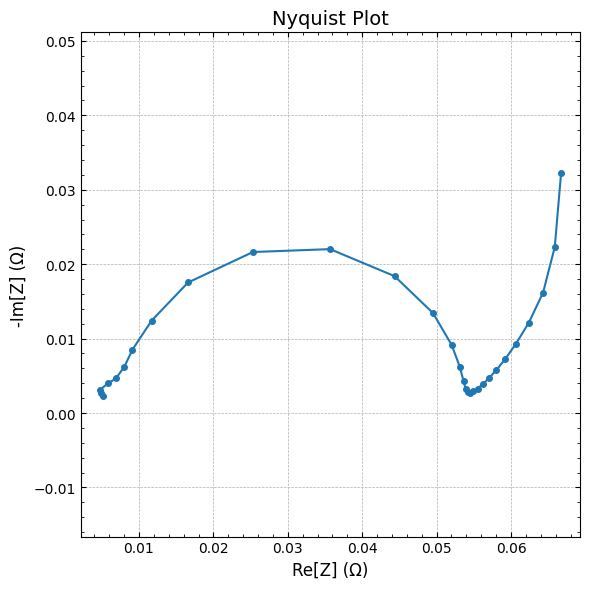

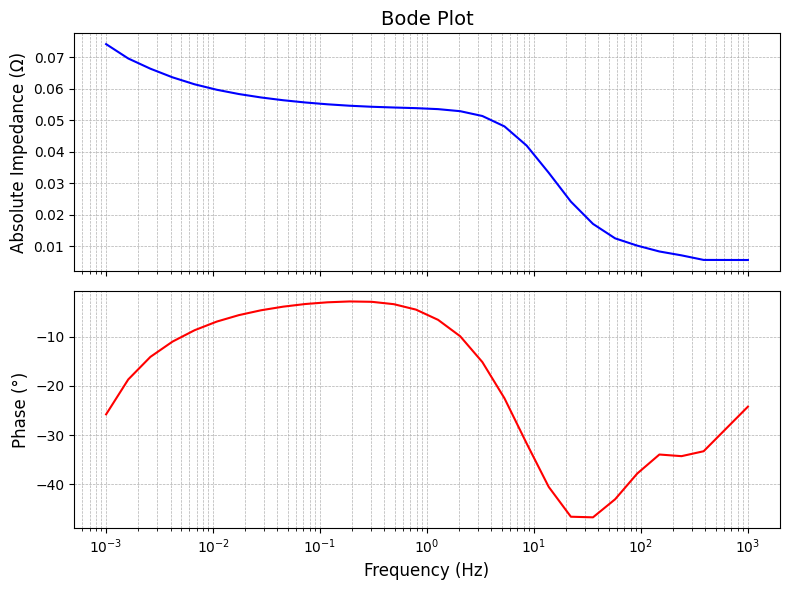

In [10]:
import numpy as np
from scipy import interpolate
from scipy import optimize
import pybamm
import matplotlib.pyplot as plt


I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 30

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    model = pybamm.lithium_ion.DFN(options={"surface form": "differential", 
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        name="Meh.",)
    # param = model.default_parameter_values 

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  



    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )
    # sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
    #                             )
    # sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,#experiment=experiment 
    #                             )

    ######################
    # t_eval = [0, 3600]
    # t_eval = np.linspace(0, 0.3, 1000)  # 1 hour simulation with 100 time points
    ######################

    # start = time.time()
    sol_DFN = sim_DFN_0.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

    # start = time.time()
    # sol_DFN_1 = sim_DFN_1.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

    # start = time.time()
    # sol_DFN_2 = sim_DFN_2.solve(t_eval=t)
    # end = time.time()
    # print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

    # param["Current function [A]"] = my_fun(I_0, freq) #TOLE VRSTICO JE TREBA NUJNO IMET, KI DEFINIRA PARAMETER TOKA, KI JE ZDAJ SINUSNA FUNKCIJA

    # sim = pybamm.Simulation(model, parameter_values=param)
    # solution = sim.solve(t_eval=t)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z[:, 1], -Z[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)', fontsize=12)
plt.ylabel('-Im[Z] (Ω)', fontsize=12)
plt.title('Nyquist Plot', fontsize=14)

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z[:, 1] + 1j * Z[:, 2])  # Combine real and imag parts
phase = np.angle(Z[:, 1] + 1j * Z[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z[:, 0]  # Assuming first column is frequency

# Create figure with two subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Magnitude plot
ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
ax[0].set_title('Bode Plot', fontsize=14)

# Phase plot
ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
ax[1].set_ylabel('Phase (°)', fontsize=12)
ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [11]:
# save data to txt file
np.savetxt("impedance_data_DFN_1.txt", Z, header="Frequency (Hz) Re[Z] (Ω) -Im[Z] (Ω)", fmt='%.6e', delimiter='\t')

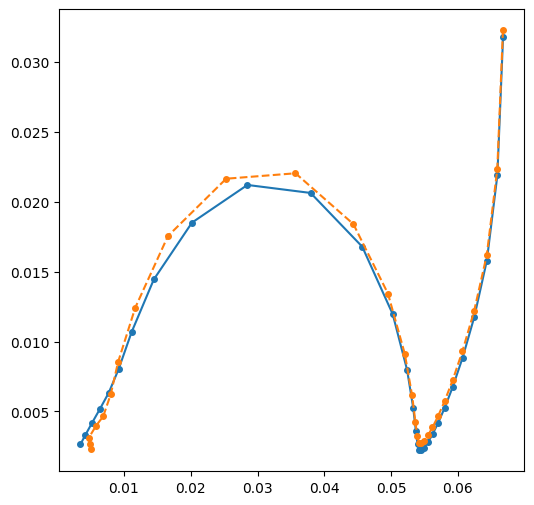

In [14]:
# import from txt
data = np.loadtxt("impedance_data_DFN.txt", skiprows=1)

re = data[:, 1]  # Real part
im = data[:, 2]  # Imaginary part
# Plotting the imported data
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(re, -im, marker='o', linestyle='-', linewidth=1.5, markersize=4)
plt.plot(Z[:, 1], -Z[:, 2], marker='o', linestyle='--', linewidth=1.5, markersize=4)

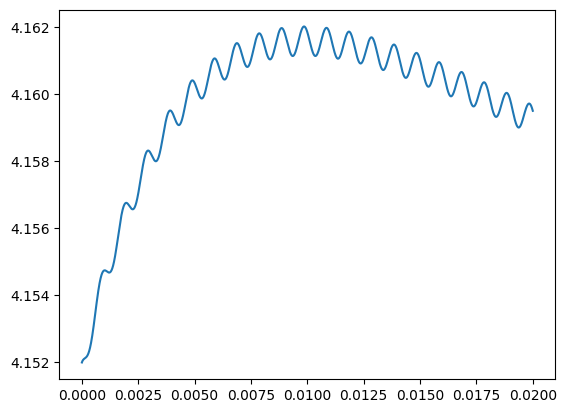

In [12]:
plt.plot(sol_DFN["Time [s]"].entries,simulated_U_L)